# Chapter B. Statistical Hypothesis Testing

## Learning Objectives

After completing this chapter, you should be able to:
1. Define a null hypothesis（原假设）and one-sided alternative for lift.
2. Derive the 2×2 table and fixed-margin hypergeometric distribution.
3. Explain conditional exchangeability（条件可交换性）and distinguish independence from a valid permutation law.
4. Compute exact and plus-one Monte Carlo p-values.
5. Explain outcome-independent screening and its limits.

**Connection to STARM:** The examples mirror the binary outcome, fixed antecedent indicators, lagged transactions, and overlapping spatial supports in the STARM manuscript. They are teaching examples, not reproductions of manuscript results.

> **Teaching philosophy:** start with the general statistical problem, build mathematical intuition, and use STARM as one illustrative case study. The new sections precede the original computational labs.

## Why Study This? — Motivation, Scope, and Real-World Problems

A statistically interesting pattern is not necessarily evidence against chance. Hypothesis testing provides a disciplined way to ask whether the data are surprising under a specific **data-generating explanation**, and makes the cost of false alarms explicit. It is used in randomized clinical trials, A/B testing, environmental monitoring, policy evaluations, and scientific discovery.

**Questions it answers:** What exactly is being tested? What distribution would we observe if the null model held? How surprising is the observed result? How much uncertainty remains?

**What it cannot answer alone:** Whether the null is true, whether the effect matters practically, or whether a statistically significant association is causal.

**Example beyond STARM:** A treatment/control trial compares the probability of improvement, and an online experiment compares conversion rates. In both, the validity of a p-value depends on the allocation or sampling model—not just the formula.

---

## Conceptual Roadmap

**Scientific problem → statistical representation → assumptions → mathematics → computational experiment → diagnostics → interpretation.**

The chapters are standalone: STARM is a later application, not the reason these mathematical ideas exist.

## Foundations and Mathematical Derivations

### From a scientific question to a test
1. Define the estimand (目标统计量), such as the risk difference $\Delta=P(Y=1\mid X=1)-P(Y=1\mid X=0)$.
2. Before examining results, state $H_0$ and $H_1$, the significance level $\alpha$, and whether the test is one- or two-sided.
3. State the sampling or randomization model. A null about equal marginal rates does **not** automatically imply that labels are exchangeable across all rows.
4. Choose a statistic $T(D)$ and calculate its reference distribution under $H_0$.
5. A p-value is $P_{H_0}(T(D^*)\text{ is at least as extreme as }T(D_{obs}))$. It is not $P(H_0\mid D)$, and it is not the probability that the result happened "by chance."

### The fixed-margin hypergeometric derivation
Suppose there are $N$ units, $n$ antecedent-positive units, and $m$ positive outcomes. Let $K$ be the number that are positive in both groups. Under a **uniform fixed-margin allocation**, there are $\binom Nm$ equally likely ways to place the $m$ positive outcomes. To obtain exactly $k$ joint positives, choose $k$ from the $n$ antecedent units and $m-k$ from the other $N-n$ units:

$$P(K=k\mid N,n,m,H_0)=\frac{\binom nk\binom{N-n}{m-k}}{\binom Nm},\qquad \max(0,m-N+n)\le k\le\min(n,m).$$

$$E[K]=n\frac mN,\qquad \mathrm{Var}(K)=n\frac mN\left(1-\frac mN\right)\frac{N-n}{N-1}.$$

The final factor $(N-n)/(N-1)$ is the finite-population correction: sampling without replacement is less variable than independent Bernoulli sampling. The lift is $L=KN/(nm)$ when $nm>0$, so $E[L]=1$ under this particular null.

### What do the hypergeometric mean and variance look like?
$E[K]$ and $\mathrm{Var}(K)$ are **numbers determined by the parameters**, not random variables with their own distributions. The random quantity is $K$, whose probability mass function (PMF) assigns probabilities to the attainable integer overlaps. For fixed $N$ and $m$, increasing $n$ makes $E[K]=nm/N$ grow linearly. The variance is zero at $n=0$ and $n=N$ and is largest near $n=N/2$; its exact values also depend on the positive-outcome fraction $m/N$.

**Example.** Imagine 50 eligible neighborhoods, 8 of which had a heat-related emergency during a defined week. A pre-specified group contains 10 neighborhoods. If the 8 events were uniformly allocated among the 50 neighborhoods under the null, then $K\sim\mathrm{Hypergeom}(50,8,10)$, $E[K]=1.6$, and $\mathrm{Var}(K)\approx1.097$ (standard deviation $\approx1.047$). The PMF is discrete and often skewed when the expected overlap is small. When the sampling fraction is small, it is close to a binomial distribution; for larger sampling fractions the finite-population correction matters.

### Type I error, Type II error, beta, and power
A hypothesis test makes a decision, but the state of the world is not observed with certainty. There are four possible outcomes:

| Truth | Decision: do not reject $H_0$ | Decision: reject $H_0$ |
|---|---|---|
| $H_0$ is true | Correct decision | **Type I error** (第一类错误), probability controlled at $\alpha$ |
| A specified alternative is true | **Type II error** (第二类错误), probability $\beta$ | Correct detection, probability **power** $=1-\beta$ |

- **Type I error ($\alpha$):** a false alarm. For example, conclude a redesign improves conversion when in truth it does not. A test designed at $\alpha=0.05$ has a 5% long-run false-rejection rate *when its null model is true*; it does not mean there is a 5% chance this particular conclusion is false.
- **Type II error ($\beta$):** a miss for a particular effect size and design. For example, conclude there is not enough evidence of improvement when the redesign truly raises conversion by 2 percentage points. $\beta$ is not a universal constant: it changes with sample size, variability, effect size, $\alpha$, and the alternative being considered.
- **Power ($1-\beta$):** the probability the planned test rejects $H_0$ if that specified alternative is true. A power of 0.80 means an 80% chance of detecting that effect under the stated assumptions, not an 80% probability that the hypothesis is true.

At a fixed sample size, lowering $\alpha$ usually raises $\beta$. More observations, less measurement noise, or a larger true effect generally increase power. Select a scientifically meaningful minimum effect and target power **before** collecting data; a post-hoc power calculation based on the observed p-value adds little information.

### Confidence intervals and effect size
A 95% confidence procedure produces intervals that cover the fixed true parameter in about 95% of repeated samples under its assumptions. After one interval has been calculated, frequentist interpretation does **not** assign a 95% probability to the fixed parameter being inside that particular interval. Report the effect size and interval as well as the p-value: with enough observations, a tiny and practically unimportant difference can have a small p-value.

### Randomization versus parametric inference
A z-test assumes a standardized statistic has an adequate reference distribution. A permutation test assumes specific allocations are exchangeable under $H_0$. A bootstrap resamples observations to approximate an estimator's sampling distribution; an ordinary row bootstrap can fail when spatial or temporal dependence is ignored. Random assignment can support a causal comparison; observational association alone cannot.

### Critical thinking checkpoint
Before running code, state which observations are assumed independent or exchangeable and why. After inspecting the plots, explain how changing the effect size or sample size changes $\beta$ and power.

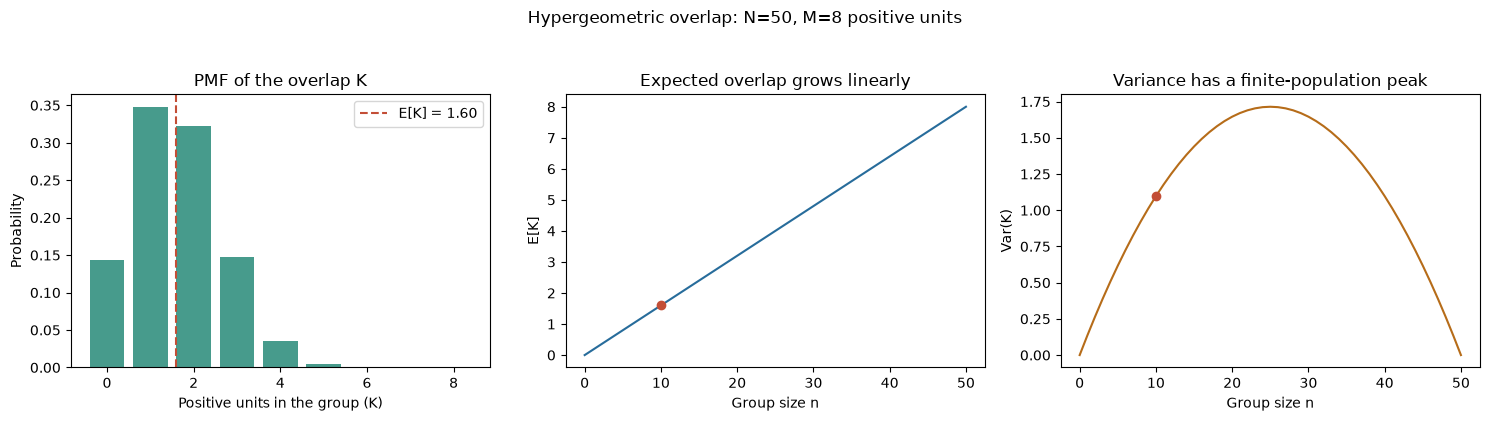

For n=10: E[K]=1.600, Var(K)=1.097, SD(K)=1.047
PMF sums to: 1.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hypergeom

# 50 neighborhoods, 8 positive outcomes, and a fixed group of 10 neighborhoods.
population_size = 50
total_positives = 8
group_size = 10
possible_overlaps = np.arange(
    max(0, group_size - (population_size - total_positives)),
    min(group_size, total_positives) + 1,
)
overlap_pmf = hypergeom.pmf(
    possible_overlaps, population_size, total_positives, group_size
)
expected_overlap = hypergeom.mean(population_size, total_positives, group_size)
variance_overlap = hypergeom.var(population_size, total_positives, group_size)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(possible_overlaps, overlap_pmf, color="#278a78", alpha=0.85)
axes[0].axvline(expected_overlap, color="#c34e36", linestyle="--", label=f"E[K] = {expected_overlap:.2f}")
axes[0].set(title="PMF of the overlap K", xlabel="Positive units in the group (K)", ylabel="Probability")
axes[0].legend()

candidate_group_sizes = np.arange(population_size + 1)
positive_fraction = total_positives / population_size
expected_by_group_size = candidate_group_sizes * positive_fraction
variance_by_group_size = (
    candidate_group_sizes
    * positive_fraction
    * (1 - positive_fraction)
    * (population_size - candidate_group_sizes)
    / (population_size - 1)
)
axes[1].plot(candidate_group_sizes, expected_by_group_size, color="#276c9b")
axes[1].scatter([group_size], [expected_overlap], color="#c34e36", zorder=3)
axes[1].set(title="Expected overlap grows linearly", xlabel="Group size n", ylabel="E[K]")
axes[2].plot(candidate_group_sizes, variance_by_group_size, color="#b66c19")
axes[2].scatter([group_size], [variance_overlap], color="#c34e36", zorder=3)
axes[2].set(title="Variance has a finite-population peak", xlabel="Group size n", ylabel="Var(K)")
fig.suptitle("Hypergeometric overlap: N=50, M=8 positive units", y=1.04)
fig.tight_layout()
plt.show()

print(f"For n={group_size}: E[K]={expected_overlap:.3f}, Var(K)={variance_overlap:.3f}, SD(K)={np.sqrt(variance_overlap):.3f}")
print("PMF sums to:", overlap_pmf.sum())

### Visualizing Type I error, Type II error, and power
For a two-sided test with significance level $\alpha=0.05$, the rejection region is in both tails of the null reference distribution. If $H_0$ is true, the probability of falling in those tails is $\alpha$ (Type I error). Under a particular alternative, the statistic's distribution shifts: the probability it still falls between the critical values is $\beta$ (Type II error), and the probability it falls in either rejection tail is power $1-\beta$.

The next plot uses a normal approximation to make those areas visible. The following simulation uses a two-proportion z-test to estimate the long-run false-alarm rate under $H_0$ and detection rate under a specified alternative. The simulated $\hat\beta$ is $1-\widehat{\text{power}}$.

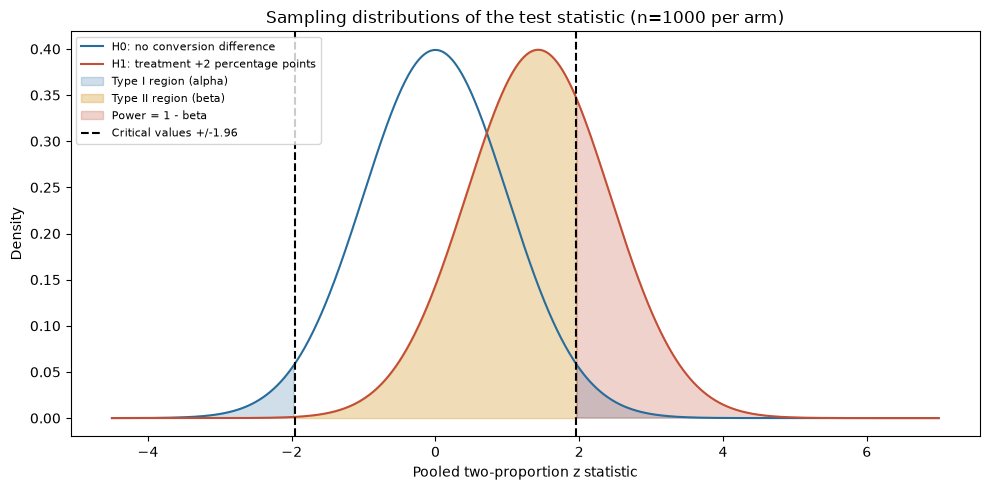

Approximate Type I rate under H0: 0.050
Approximate beta under this H1: 0.702
Approximate power under this H1: 0.298


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

alpha = 0.05
control_rate = 0.10
treatment_rate = 0.12
sample_size_per_arm = 1000
pooled_rate_under_null = (control_rate + treatment_rate) / 2
null_standard_error = np.sqrt(
    pooled_rate_under_null * (1 - pooled_rate_under_null) * 2 / sample_size_per_arm
)
alternative_standard_error = np.sqrt(
    control_rate * (1 - control_rate) / sample_size_per_arm
    + treatment_rate * (1 - treatment_rate) / sample_size_per_arm
)
critical_value = norm.ppf(1 - alpha / 2)
alternative_mean_z = (treatment_rate - control_rate) / null_standard_error
alternative_sd_z = alternative_standard_error / null_standard_error
z_values = np.linspace(-4.5, 7, 1000)
null_density = norm.pdf(z_values)
alternative_density = norm.pdf(
    z_values, loc=alternative_mean_z, scale=alternative_sd_z
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(z_values, null_density, color="#276c9b", label="H0: no conversion difference")
ax.plot(z_values, alternative_density, color="#c34e36", label="H1: treatment +2 percentage points")
ax.fill_between(z_values, 0, null_density, where=np.abs(z_values) >= critical_value, color="#276c9b", alpha=0.22, label="Type I region (alpha)")
ax.fill_between(z_values, 0, alternative_density, where=np.abs(z_values) < critical_value, color="#d9a441", alpha=0.38, label="Type II region (beta)")
ax.fill_between(z_values, 0, alternative_density, where=np.abs(z_values) >= critical_value, color="#c34e36", alpha=0.25, label="Power = 1 - beta")
ax.axvline(-critical_value, color="black", linestyle="--")
ax.axvline(critical_value, color="black", linestyle="--", label=f"Critical values +/-{critical_value:.2f}")
ax.set(title=f"Sampling distributions of the test statistic (n={sample_size_per_arm} per arm)", xlabel="Pooled two-proportion z statistic", ylabel="Density")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

approximate_power = norm.cdf(-critical_value, loc=alternative_mean_z, scale=alternative_sd_z) + norm.sf(critical_value, loc=alternative_mean_z, scale=alternative_sd_z)
print(f"Approximate Type I rate under H0: {2 * norm.sf(critical_value):.3f}")
print(f"Approximate beta under this H1: {1 - approximate_power:.3f}")
print(f"Approximate power under this H1: {approximate_power:.3f}")

### Simulation demo: sample size, alpha, beta, and power
Now simulate a planned A/B test with a 10% control conversion rate and a scientifically relevant alternative of 12%. Under the null, both groups convert at 10%; under the alternative, treatment converts at 12%. For each sample size, repeated datasets estimate the false-positive rate $\alpha$, power, and $\beta=1-\text{power}$. The curves fluctuate slightly because this is a finite Monte Carlo experiment; the declared seed makes it reproducible.

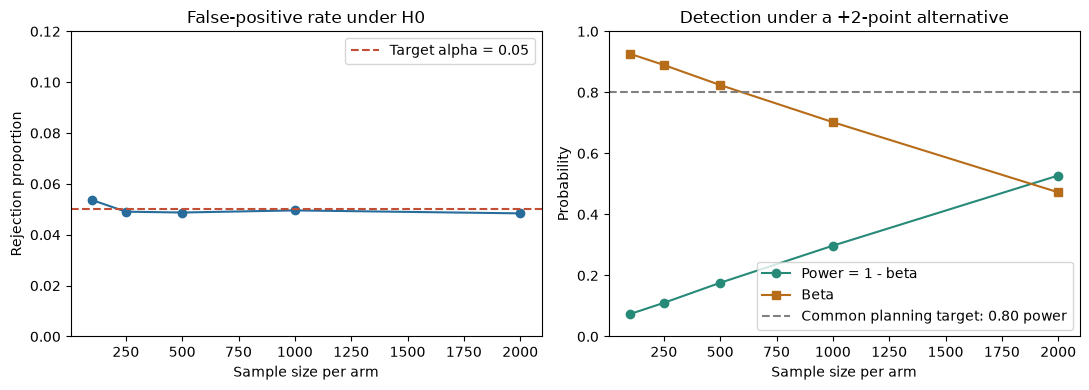

 n per arm  estimated Type I rate  estimated beta  estimated power
       100                  0.054           0.926            0.074
       250                  0.049           0.890            0.110
       500                  0.049           0.824            0.176
      1000                  0.050           0.702            0.298
      2000                  0.048           0.473            0.528


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

simulation_seed = 20261008
simulation_rng = np.random.default_rng(simulation_seed)
sample_sizes = np.array([100, 250, 500, 1000, 2000])
simulation_count = 12000
alpha = 0.05
null_rate = 0.10
alternative_rate = 0.12
critical_value = norm.ppf(1 - alpha / 2)

def reject_two_proportion_null(control_counts, treatment_counts, n):
    pooled_rate = (control_counts + treatment_counts) / (2 * n)
    standard_error = np.sqrt(pooled_rate * (1 - pooled_rate) * 2 / n)
    z_statistic = np.divide(
        treatment_counts / n - control_counts / n,
        standard_error,
        out=np.zeros_like(pooled_rate, dtype=float),
        where=standard_error > 0,
    )
    return np.abs(z_statistic) > critical_value

null_control = simulation_rng.binomial(
    sample_sizes[:, None], null_rate, size=(len(sample_sizes), simulation_count)
)
null_treatment = simulation_rng.binomial(
    sample_sizes[:, None], null_rate, size=(len(sample_sizes), simulation_count)
)
alternative_control = simulation_rng.binomial(
    sample_sizes[:, None], null_rate, size=(len(sample_sizes), simulation_count)
)
alternative_treatment = simulation_rng.binomial(
    sample_sizes[:, None], alternative_rate, size=(len(sample_sizes), simulation_count)
)

estimated_alpha = reject_two_proportion_null(null_control, null_treatment, sample_sizes[:, None]).mean(axis=1)
estimated_power = reject_two_proportion_null(alternative_control, alternative_treatment, sample_sizes[:, None]).mean(axis=1)
estimated_beta = 1 - estimated_power
power_results = pd.DataFrame({
    "n per arm": sample_sizes,
    "estimated Type I rate": estimated_alpha,
    "estimated beta": estimated_beta,
    "estimated power": estimated_power,
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(sample_sizes, estimated_alpha, marker="o", color="#276c9b")
axes[0].axhline(alpha, color="#c34e36", linestyle="--", label=f"Target alpha = {alpha:.2f}")
axes[0].set(title="False-positive rate under H0", xlabel="Sample size per arm", ylabel="Rejection proportion", ylim=(0, 0.12))
axes[0].legend()
axes[1].plot(sample_sizes, estimated_power, marker="o", color="#278a78", label="Power = 1 - beta")
axes[1].plot(sample_sizes, estimated_beta, marker="s", color="#b66c19", label="Beta")
axes[1].axhline(0.80, color="gray", linestyle="--", label="Common planning target: 0.80 power")
axes[1].set(title="Detection under a +2-point alternative", xlabel="Sample size per arm", ylabel="Probability", ylim=(0, 1))
axes[1].legend()
fig.tight_layout()
plt.show()
print(power_results.round(3).to_string(index=False))

### Real-world use case: evaluating a checkout redesign
A product team randomizes eligible visitors to the current checkout (control) or a redesigned checkout (treatment), then records whether each visitor completes a purchase. The outcome is binary, so a two-proportion test can assess the conversion-rate difference. The values below are **constructed teaching data**, not a claim about a particular company's experiment.

Suppose each arm has 30,000 unique visitors: 3,000 purchases in control and 3,240 in treatment. The observed absolute difference is 0.8 percentage points. The code calculates a two-sided pooled z-test and a 95% Wald confidence interval for the unpooled risk difference. Before acting, the team should also consider the interval's range of plausible business impact, implementation cost, randomization integrity, repeated users, experiment peeking, and whether this was one of many tested outcomes. Statistical significance alone does not establish worthwhile value.

In [4]:
import numpy as np
from scipy.stats import norm

control_visitors = 30_000
control_purchases = 3_000
treatment_visitors = 30_000
treatment_purchases = 3_240
alpha = 0.05

control_rate_hat = control_purchases / control_visitors
treatment_rate_hat = treatment_purchases / treatment_visitors
risk_difference = treatment_rate_hat - control_rate_hat
pooled_rate = (control_purchases + treatment_purchases) / (control_visitors + treatment_visitors)
null_standard_error = np.sqrt(
    pooled_rate * (1 - pooled_rate)
    * (1 / control_visitors + 1 / treatment_visitors)
)
z_statistic = risk_difference / null_standard_error
p_value = 2 * norm.sf(abs(z_statistic))

confidence_standard_error = np.sqrt(
    control_rate_hat * (1 - control_rate_hat) / control_visitors
    + treatment_rate_hat * (1 - treatment_rate_hat) / treatment_visitors
)
ci_lower = risk_difference - norm.ppf(0.975) * confidence_standard_error
ci_upper = risk_difference + norm.ppf(0.975) * confidence_standard_error

print(f"Control conversion:   {control_rate_hat:.2%} ({control_purchases:,}/{control_visitors:,})")
print(f"Treatment conversion: {treatment_rate_hat:.2%} ({treatment_purchases:,}/{treatment_visitors:,})")
print(f"Absolute difference:  {risk_difference:.2%} ({risk_difference * 100:.2f} percentage points)")
print(f"95% Wald CI:          [{ci_lower:.2%}, {ci_upper:.2%}]")
print(f"Two-sided z statistic: {z_statistic:.3f}")
print(f"Two-sided p-value:     {p_value:.6g}")
print(f"Estimated extra purchases per 10,000 visitors: {risk_difference * 10_000:.0f}")
print("Decision at alpha=0.05:", "reject H0" if p_value < alpha else "do not reject H0")

Control conversion:   10.00% (3,000/30,000)
Treatment conversion: 10.80% (3,240/30,000)
Absolute difference:  0.80% (0.80 percentage points)
95% Wald CI:          [0.31%, 1.29%]
Two-sided z statistic: 3.210
Two-sided p-value:     0.00132872
Estimated extra purchases per 10,000 visitors: 80
Decision at alpha=0.05: reject H0


## Additional Derivation Visualization — General-Purpose Example

The following self-contained experiment illustrates a general statistical principle, not STARM-specific results. Check how the plot corresponds to the formulas above.

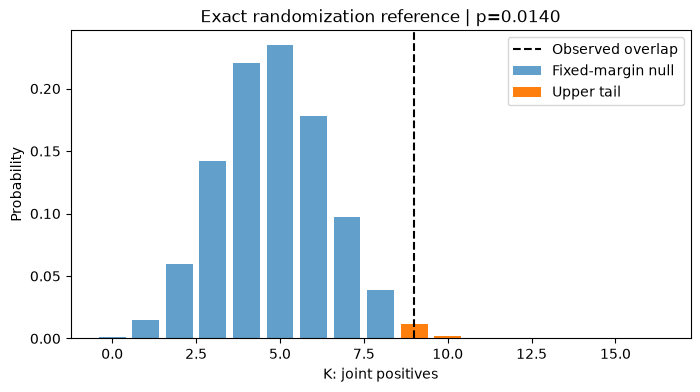

Expected K: 4.8 Observed lift: 1.875


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hypergeom, norm
N, n, m = 80, 24, 16
k = np.arange(max(0,m-(N-n)), min(n,m)+1)
pmf = hypergeom.pmf(k,N,m,n)
observed_k = 9
pvalue = hypergeom.sf(observed_k-1,N,m,n)
fig,ax=plt.subplots(figsize=(8,4))
ax.bar(k,pmf,alpha=.7,label='Fixed-margin null')
ax.bar(k[k>=observed_k],pmf[k>=observed_k],label='Upper tail')
ax.axvline(observed_k,color='black',ls='--',label='Observed overlap')
ax.set(xlabel='K: joint positives',ylabel='Probability',title=f'Exact randomization reference | p={pvalue:.4f}')
ax.legend();plt.show()
print('Expected K:',n*m/N,'Observed lift:', observed_k*N/(n*m))

```mermaid
flowchart LR
    A[Define eligible transactions] --> B[Freeze X candidates]
    B --> C[Specify allocation null]
    C --> D[Compute observed lift]
    D --> E[Exact or Monte Carlo tail]
    E --> F[Assess assumptions]
```

This chapter follows the same structure as the supplied MCLP tutorial: conceptual workflow, formal definition, assumptions, a hand-worked example, executable Python experiments, sensitivity checks, common pitfalls, and a quiz.

---

## Formal Definition and Core Equations

### Notation

| Symbol | Meaning |
|---|---|
| $N$ | number of eligible anchor-period transactions |
| $m=\sum_i Y_i$ | target-positive count（阳性交易数量） |
| $n=\sum_i X_i$ | antecedent-positive count |
| $K=\sum_i X_iY_i$ | co-occurrence count |
| $X_i,Y_i\in\{0,1\}$ | antecedent, target indicators |
| $L$ | lift（提升度） |

$$\widehat L=\frac{K/n}{m/N}=\frac{KN}{nm},\qquad K\mid X,N,m\sim\mathrm{Hypergeom}(N,m,n)$$

$$p_{\rm exact}=P(K^*\ge K_{\rm obs}\mid N,m,n),\qquad \hat p_{MC}=\frac{1+\sum_{b=1}^{B}\mathbf{1}(L_b^*\ge L_{obs})}{B+1}.$$

---

## Core Mechanisms and Concepts

### What is a valid null?

The candidate-level statement $P(Y=1\mid X=1)=P(Y=1)$ is weaker than **uniform allocation of the whole target vector** conditional on the number of positives. Permuting the $Y$ rows tests that stronger allocation law, not every possible notion of independence.

### Fixed-margin conditioning

Holding $N,m,n$ fixed leaves only $K$ random. This yields a hypergeometric tail and makes confidence and lift monotone functions of $K$. The same candidate frequency leads to the same reference distribution under this particular null.

### Discrete exact tests

The attainable values of $K$ are integers, so exact p-values can be conservative. Monte Carlo ranks use **plus one** to avoid zero p-values, but more permutations cannot repair an incorrect null.

### Screening

Support screening computed using $X$ alone freezes candidates before looking at $Y$. It avoids outcome-driven selection, but does **not** by itself ensure conditional exchangeability or BH validity.

## Assumptions, Strengths, Limitations, and Trade-offs

Assume binary measurements are accurate, the candidate set is fixed independently of target outcomes, and each allocation of the $m$ positives to $N$ rows is equally likely under the null. Strength: finite-sample exact conditional reference. Limit: spatially shared events, seasonality, uneven risk, and serial dependence often violate this allocation model.

**Trade-off:** conditioning on the observed total removes uncertainty about baseline prevalence but does not preserve the geography of event occurrence.

## Worked Toy Example

For $N=12$ sampled neighborhood-months, $m=4$ wildfire-positive contexts, and $n=5$ neighborhoods satisfying a lagged dry predicate, suppose $K=3$ co-occurrences.

$$\widehat L=\frac{3/5}{4/12}=1.8.$$

Under complete label exchangeability, calculate $P(K^*\ge3)$ from $\mathrm{Hypergeom}(12,4,5)$. A lift above one is not equivalent to statistical significance.

## Python Lab: Set Up the Dataset

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import hypergeom, binom

SEED = 41020001
rng = np.random.default_rng(SEED)
print("Reproducible random seed:", SEED)

Reproducible random seed: 41020001


## Build the 2×2 table

Use a transparent binary example to check every denominator.

In [7]:
N,m,n,K=12,4,5,3
obs=pd.DataFrame([[K,n-K],[m-K,N-m-n+K]],index=['X=1','X=0'],columns=['Y=1','Y=0'])
print(obs)
print('support=',K/N,'confidence=',K/n,'lift=',K*N/(n*m))

     Y=1  Y=0
X=1    3    2
X=0    1    6
support= 0.25 confidence= 0.6 lift= 1.8


**Interpretation.** Rule support is joint prevalence; antecedent support is n/N. The rows of the table must sum to n and N−n.

## Evaluate an exact tail

The hypergeometric null fixes the two margins.

Exact one-sided p-value: 0.151515


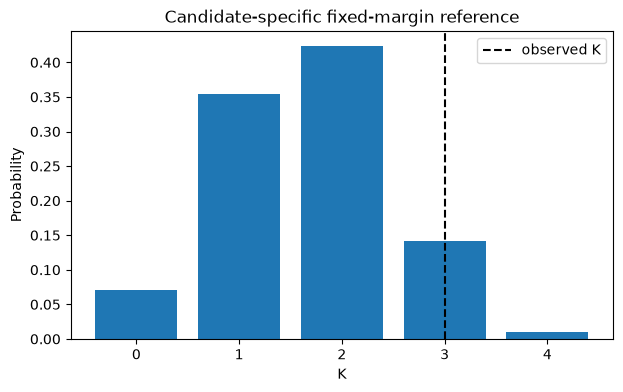

In [8]:
ks=np.arange(max(0,n+m-N),min(n,m)+1)
probs=hypergeom.pmf(ks,N,m,n)
p_exact=hypergeom.sf(K-1,N,m,n)
print('Exact one-sided p-value:',round(p_exact,6))
fig,ax=plt.subplots(figsize=(7,4));ax.bar(ks,probs);ax.axvline(K,color='black',linestyle='--',label='observed K');ax.set(xlabel='K',ylabel='Probability',title='Candidate-specific fixed-margin reference');ax.legend();plt.show()

**Interpretation.** The exact tail sums all attainable overlaps at least as large as the observed overlap.

## Run the Monte Carlo test

Compare permutation approximation to the exact reference without using forbidden zero p-values.

In [9]:
B=9999
X=np.r_[np.ones(n,dtype=int),np.zeros(N-n,dtype=int)]
Y=np.r_[np.ones(m,dtype=int),np.zeros(N-m,dtype=int)]
K_perm=np.array([np.dot(X,rng.permutation(Y)) for _ in range(B)])
p_mc=(1+np.count_nonzero(K_perm>=K))/(B+1)
print({'exact':p_exact,'Monte Carlo plus-one':p_mc,'minimum_possible_MC_p':1/(B+1)})

{'exact': np.float64(0.15151515151515152), 'Monte Carlo plus-one': np.float64(0.1496), 'minimum_possible_MC_p': 0.0001}


**Interpretation.** Agreement of exact and Monte Carlo tails checks computation under the SAME null; it does not check whether the null is geographically justified.

## Explore the sensitivity to support

For a fixed total prevalence, changing candidate prevalence changes the attainable null spread.

In [10]:
rows=[]
for nn in [3,5,7,9]:
 kk=min(nn,m)
 rows.append({'antecedent_count':nn,'E[K]':nn*m/N,'Var[K]':hypergeom.var(N,m,nn),'P(K>=max)':hypergeom.sf(kk-1,N,m,nn)})
print(pd.DataFrame(rows).round(4))

   antecedent_count    E[K]  Var[K]  P(K>=max)
0                 3  1.0000  0.5455     0.0182
1                 5  1.6667  0.7071     0.0101
2                 7  2.3333  0.7071     0.0707
3                 9  3.0000  0.5455     0.2545


**Interpretation.** Candidate-specific uncertainty changes with n even when background event prevalence remains constant.

---

## Common Pitfalls and Misunderstandings

1. **Lift > 1 is not a p-value.**
2. **Marginal independence does not imply row-exchangeability.**
3. **Permuting labels is not the same as simulating a spatial point process.**
4. **Using more permutations does not solve model misspecification.**
5. **Outcome-free candidate screening does not prove multiplicity control.**

---

## Quiz — Self-Assessment (Answers Hidden)

Try each question before expanding **Answer**. The folded format follows the supplied `mclp.ipynb` template.

### Q1: Why is learning a sampling or randomization model necessary before using a p-value?

A. It guarantees a small p-value  
B. It defines how unusual results are calculated under the null  
C. It determines a causal effect  
D. It eliminates bias

<details>
<summary>Answer</summary>

**B. The model defines the reference distribution; a formula alone is not a validity guarantee.**

</details>

---

### Q2: Under the fixed-margin model, what is held constant?

A. The sample mean only  
B. N, antecedent count n, and positive-outcome count m  
C. Every individual outcome  
D. The observed overlap K

<details>
<summary>Answer</summary>

**B. Only the margins and eligible units are fixed; K varies across allocations.**

</details>

---

### Q3: Does a p-value of 0.03 mean that the null is 3% likely?

A. Yes  
B. Only with 1,000 samples  
C. No  
D. Only for one-sided tests

<details>
<summary>Answer</summary>

**C. It is a probability of a statistic at least as extreme under the specified null reference, not a posterior probability.**

</details>

---

### Q4: Why might a conventional row bootstrap fail for spatial data?

A. It uses too many draws  
B. It treats dependent rows as independent  
C. It requires binary data  
D. It is always conservative

<details>
<summary>Answer</summary>

**B. Resampling single units destroys dependence; block or model-based resampling may be required.**

</details>

---

### Reflection Question (no prescribed solution)

Name one assumption violation in your own research area and propose a simulation to measure how much it matters.


---

## Suggested Reading and STARM Crosswalk

- Agrawal & Srikant (1994): frequent-itemset search (background).
- Hope (1968); Phipson & Smyth (2010): randomization/Monte Carlo p-values (Chapter B).
- Benjamini & Hochberg (1995); Benjamini & Yekutieli (2001): multiple testing and dependence (Chapter C).
- Baddeley, Rubak & Turner (2015): spatial point patterns (Chapter D).
- Winkler et al. (2014): exchangeability blocks and permutation designs (Chapters B, D, E).
- STARM manuscript: Sections 3.3–3.6 for reference assumptions; Section 4 for simulations; Sections 5–6 for empirical limitations.

**Practice task:** Write a short reviewer note distinguishing a descriptive association from an inferential discovery, explicitly naming the null model and its assumptions.